# Titanic - Machine Learning from Disaster

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Inspired and modified in accordance with**: [Titanic - Advanced Feature Engineering Tutorial](https://www.kaggle.com/code/gunesevitan/titanic-advanced-feature-engineering-tutorial#3.-Model)

## Packages installation and libraries importation

In [66]:
pip install pandas numpy matplotlib seaborn torch scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [67]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis

### Data overview

In [176]:
df_train = pd.read_csv('../data/raw/train.csv')
print(f"Initial dataset shape: {df_train.shape}")
print(df_train.shape)
print(df_train.info())
df_train.head()

Initial dataset shape: (891, 12)
(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [177]:
df_test = pd.read_csv('../data/raw/test.csv')
print(f"Test dataset shape: {df_test.shape}")
print(df_test.shape)
print(df_test.info())
df_test.head()

Test dataset shape: (418, 11)
(418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [178]:
df_train = df_train.drop(['PassengerId'], axis=1)

- Survived:
    + 1: Survived
    + 0: Not survived

- Pclass: A proxy for socio-economic status (SES)
    + 1st = Upper
    + 2nd = Middle
    + 3rd = Lower

- Age: Age is fractional if less than 1, it in the form of x.5 if estimated

- Sibsp:
    + Sibling = brother, sister, stepbrother, stepsister
    + Spouse = husband, wife (mistresses and fiances were ignored)

- Parch:
    + Parent = mother, father
    + Child = daughter, son, stepdaughter, stepson
    + Some children travelled only with a nanny, therefore parch=0 for them.

- Ticket: Families or groupes had purchased tickets together shared the same ticket number. However, they tickets can be different if there were multiple transactions.

- Fare: The price of ticket, can be associated with family size

- Cabin: Range from A-G with 80% missing values

- Embarked: Where the passengers boarded the ship: Cherbourg, Queenstown, Southampton

### Plot functions

In [179]:
def group_by_col_and_plot(df, col):
    gr = df.groupby(col, observed=False).size().to_frame(name='Count')
    gr['Ratio'] = np.round(gr['Count'] / gr['Count'].sum() * 100, 0)
    
    print(f'Total number of {col}: {gr["Count"].sum()}')
    
    colors = sns.color_palette(n_colors=len(gr))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr['Count'].plot(kind='bar', ax=ax1, color=colors, title=f'{col} Counts')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr['Ratio'].plot(kind='pie', ax=ax2, colors=colors, title=f'{col} Ratio', autopct='%1.1f%%', ylabel='')   

    plt.tight_layout()
    plt.show()
    

In [180]:
def distribution_plot(df, col):
    surv = df['Survived'] == 1

    _, ax = plt.subplots(1, 1, figsize=(12, 12))

    # Distribution of survival in feature
    sns.histplot(data=df, x=df[~surv][col], label='Not Survived', kde=True, color='#e74c3c')   
    sns.histplot(data=df, x=df[surv][col] , label='Survived', kde=True, color='#2ecc71')
        
    ax.set_xlabel('')
        
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
        
    ax.legend(loc='upper right', prop={'size': 20})
    ax.set_title('Distribution of Survival in {}'.format(col), size=20, y=1.05)
            
    plt.show()

In [181]:
from scipy import stats
def is_significant(gr, threshold=0.05):
    # Chi-Square Test
    chi2, p, _, _ = stats.chi2_contingency(gr)
    
    # Cramer's V Calculation
    n = gr.sum().sum()
    min_dim = min(gr.shape[0], gr.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    # Interpretation
    if cramers_v <= 0.2:
        strength = "weak"
    elif cramers_v <= 0.6:
        strength = "moderate"
    else:
        strength = "strong"

    if p < threshold:
        print(f"Result: statistically significant (p = {p:.5e})")
        print(f"Correlation (Cramér's V): {cramers_v:.3f} ({strength} association)")
    else:
        print(f"Result: statistically insignificant (p = {p:.5e})")
        print(f"Correlation (Cramér's V): {cramers_v:.3f} ({strength} association)")
    

def group_by_2_cols(df, col_1, col_2):
    gr = df.groupby([col_1, col_2], observed=False).size().unstack(col_1, fill_value=0)
    print(gr)
    
    return gr

def plot_2_cols_chart(gr, col_1, col_2):
    gr_total = gr.sum(axis=1)
    gr = np.round(gr.divide(gr_total, axis=0) * 100, 2)
    gr_total_percentage = np.round((gr_total/gr_total.sum())*100, 2)
    
    colors = sns.color_palette(n_colors=sum(gr.nunique()))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr.plot(kind='bar', ax=ax1, color=colors, title=f'Proportion of {col_1} per {col_2}')
    
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.2f')
    
    ax1.set_xlabel('')
    ax1.set_ylabel('%', rotation=1)
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr_total_percentage.plot(kind='pie', ax=ax2, colors=colors, title=f'{col_1} Ratio', autopct='%1.1f%%', ylabel='')  

    plt.tight_layout()
    plt.show()
    
    return

### Sex

Total number of Sex: 891


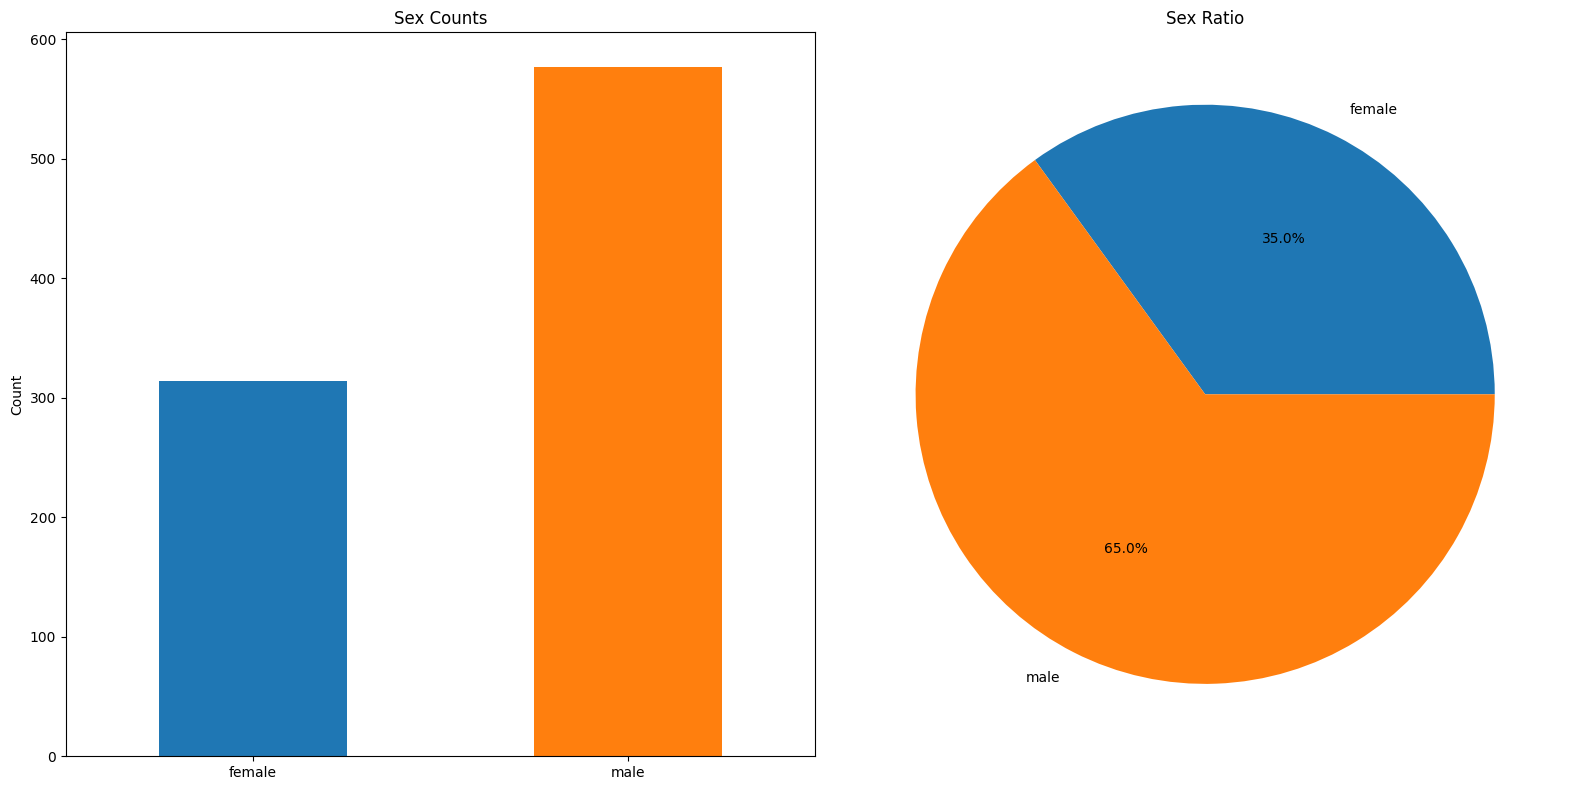

In [182]:
group_by_col_and_plot(df_train, col='Sex')

Survived    0    1
Sex               
female     81  233
male      468  109


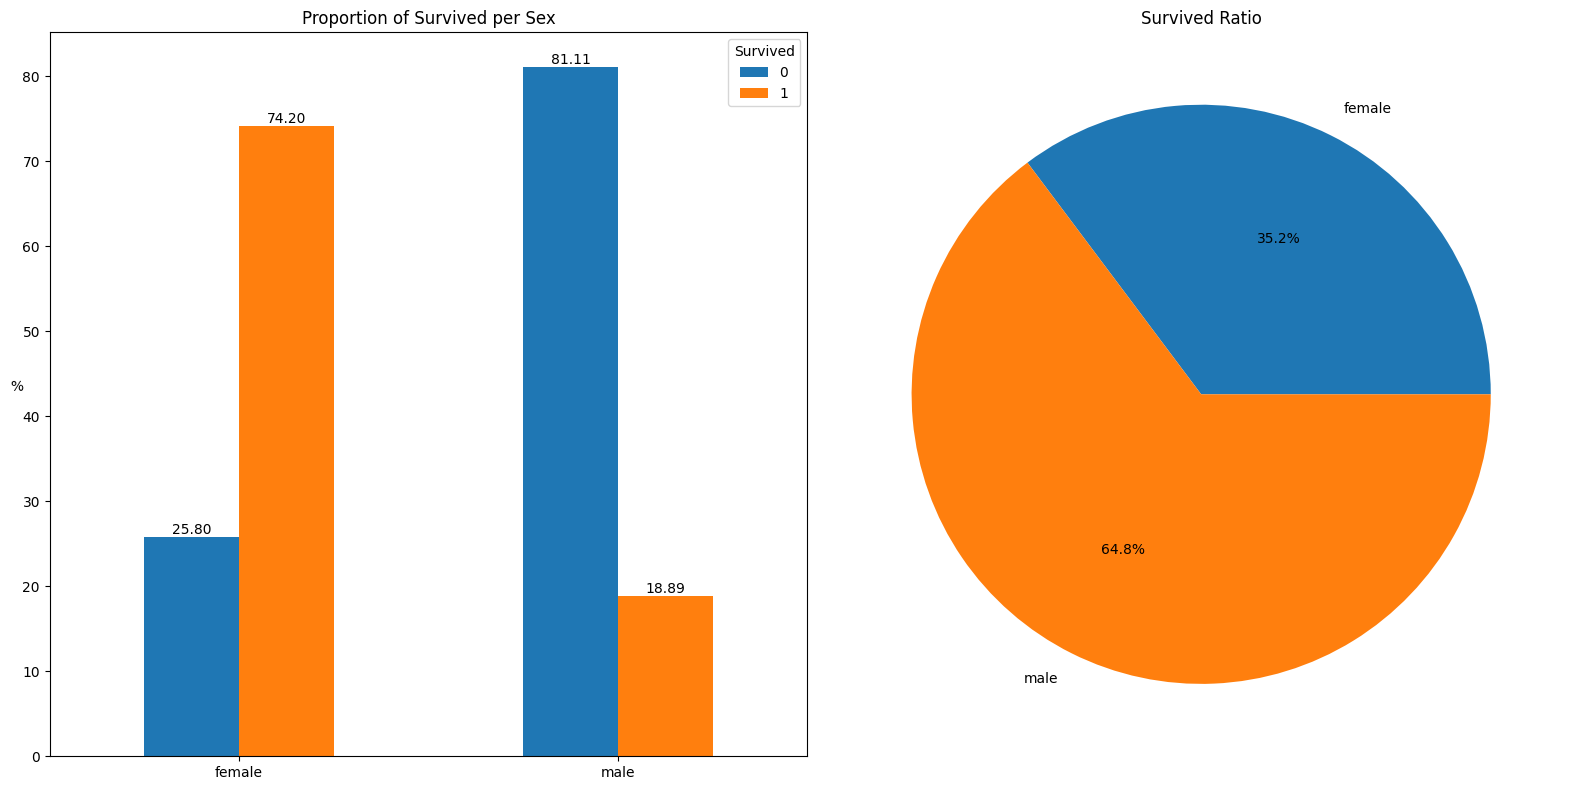

Result: statistically significant (p = 1.19736e-58)
Correlation (Cramér's V): 0.541 (moderate association)


In [183]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Sex')
plot_2_cols_chart(gr, col_1='Survived', col_2='Sex')
is_significant(gr)

Gender was the dominant predictor of survival with females had a 74.2% survival rate while males had only an 18.9% survival rate.

### Age

In [184]:
age_by_pclass_sex = df_train.groupby(['Sex', 'Pclass'])['Age'].median()

for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median age of Pclass {} {}s: {}'.format(pclass, sex, age_by_pclass_sex[sex][pclass]))
print('Median age of all passengers: {}'.format(df_train['Age'].median()))

Median age of Pclass 1 females: 35.0
Median age of Pclass 1 males: 40.0
Median age of Pclass 2 females: 28.0
Median age of Pclass 2 males: 30.0
Median age of Pclass 3 females: 21.5
Median age of Pclass 3 males: 25.0
Median age of all passengers: 28.0


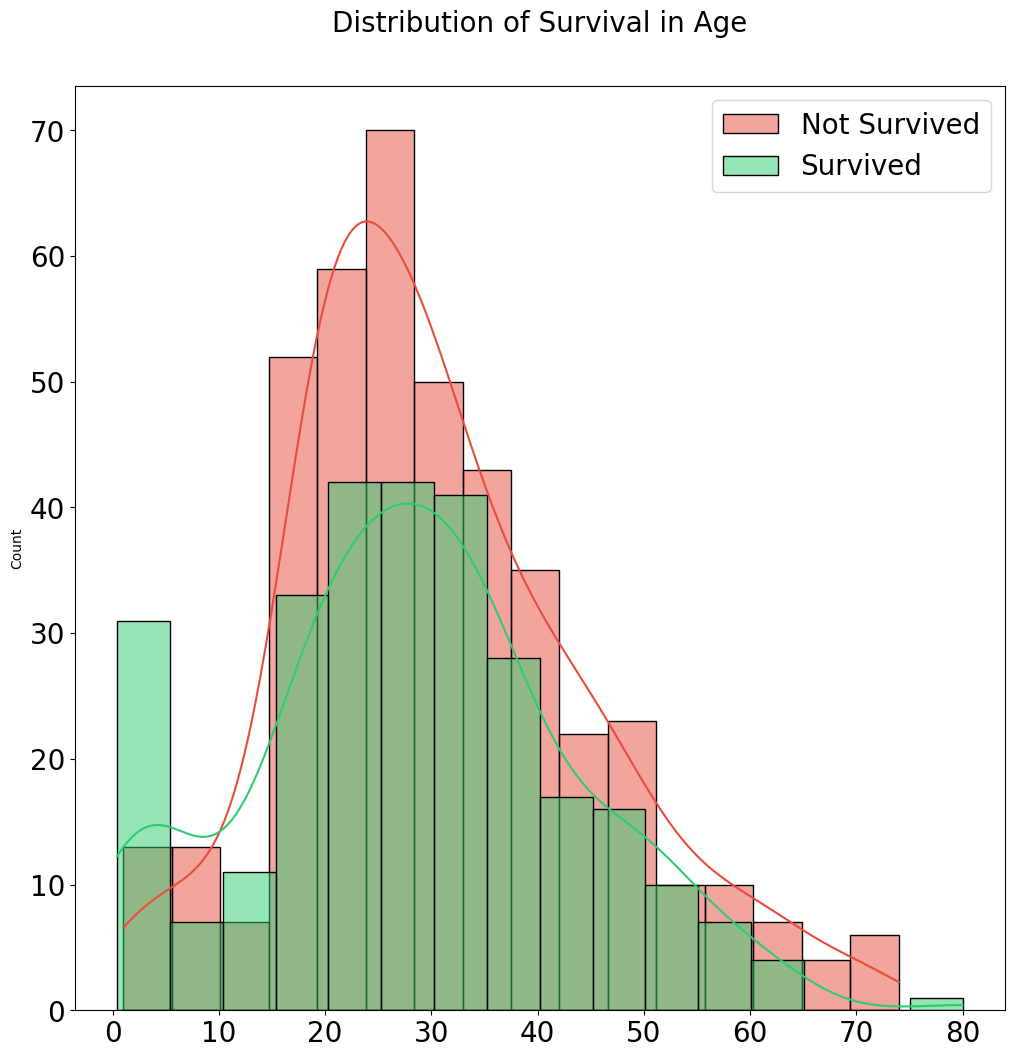

In [185]:
distribution_plot(df=df_train, col='Age')

The green "Survived" distribution shows a significant peak in the 0–10 age range, whereas the red "Not Survived" distribution is much lower in this bracket. The "Not Survived" group (red) has a much sharper and higher peak (reaching ~70 individuals) centered around ages 20–30. This indicates that the largest demographic of victims was young adults. Children seems to be a decisive factor for survivability.

### Fare

In [186]:
fare_by_pclass_sex = df_train.groupby(['Sex', 'Pclass'])['Fare'].median()

for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median fare of Pclass {} {}s: {}'.format(pclass, sex, fare_by_pclass_sex[sex][pclass]))
print('Median fare of all passengers: {}'.format(df_train['Fare'].median()))

Median fare of Pclass 1 females: 82.66454999999999
Median fare of Pclass 1 males: 41.2625
Median fare of Pclass 2 females: 22.0
Median fare of Pclass 2 males: 13.0
Median fare of Pclass 3 females: 12.475
Median fare of Pclass 3 males: 7.925
Median fare of all passengers: 14.4542


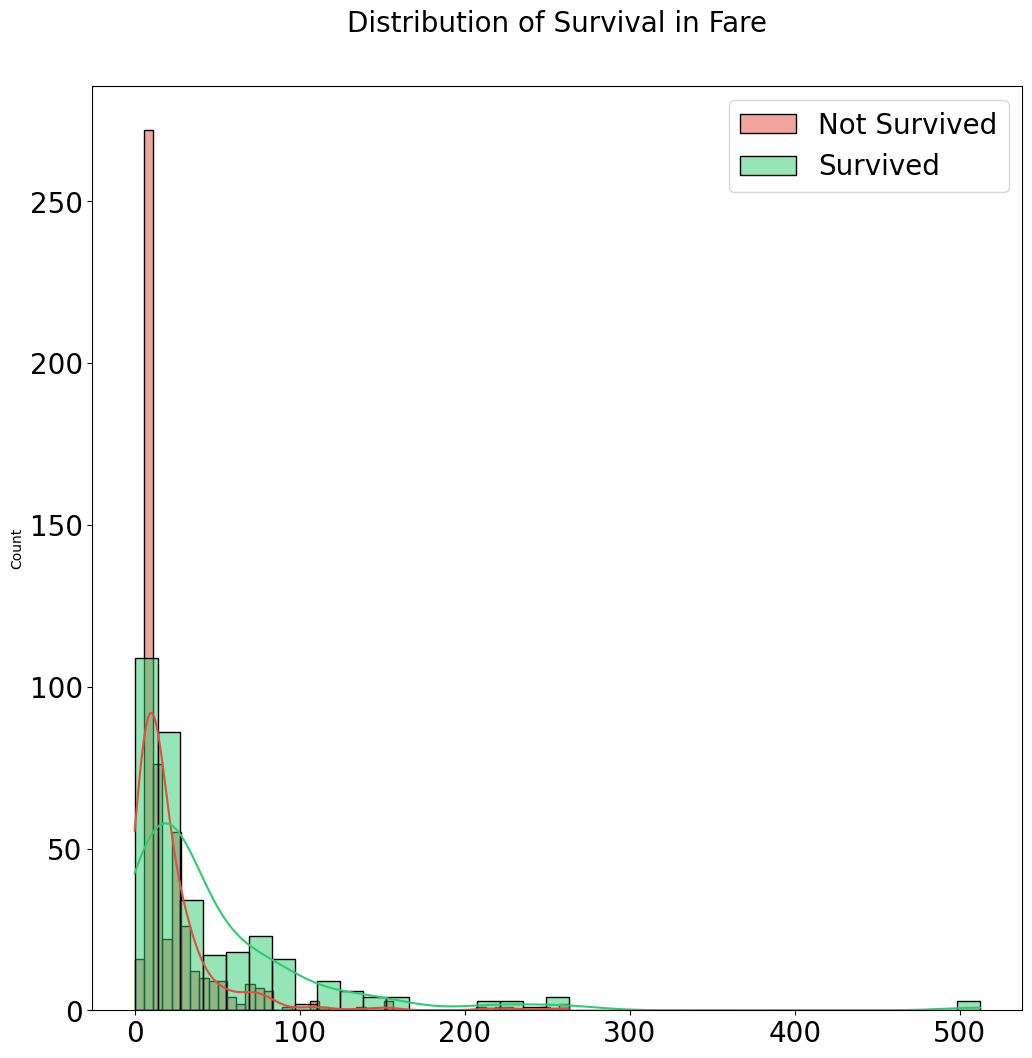

In [187]:
distribution_plot(df=df_train, col='Fare')

While the red "Not Survived" curve dominates the low-fare section, the green "Survived" curve is much more prominent in the higher fare ranges. This indicates that the vast majority of victims were passengers with the cheapest tickets (likely 3rd Class), who faced the greatest barriers to reaching the boat deck. The "Survived" distribution is flatter and extends further to the right. While many survivors also paid low fares, the proportion of survivors increases steadily as the fare price increases.

### Embarked

Total number of Embarked: 889


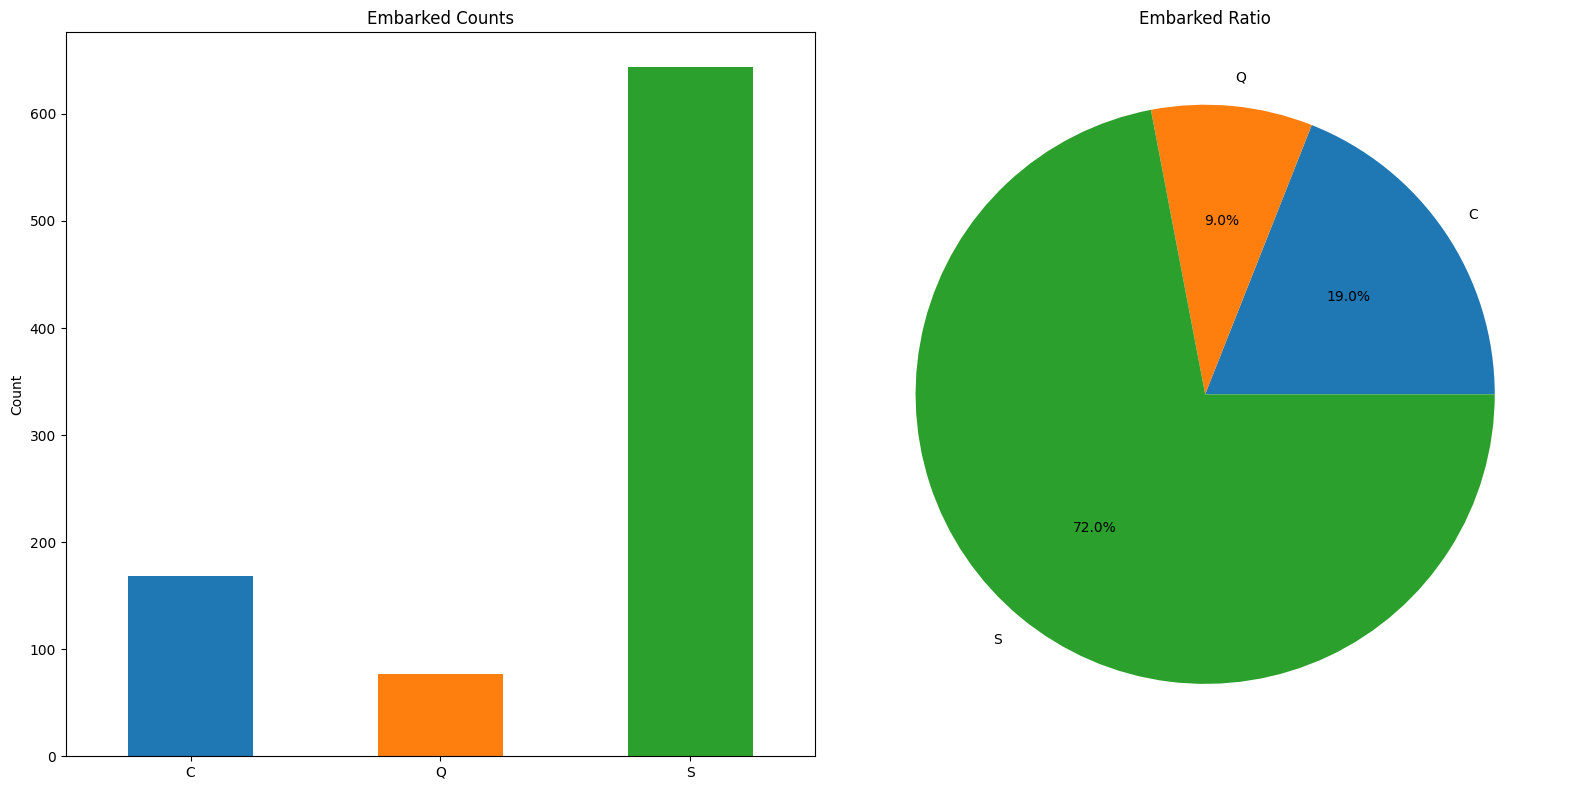

In [188]:
group_by_col_and_plot(df_train, col='Embarked')

Pclass      1    2    3
Embarked               
C          85   17   66
Q           2    3   72
S         127  164  353


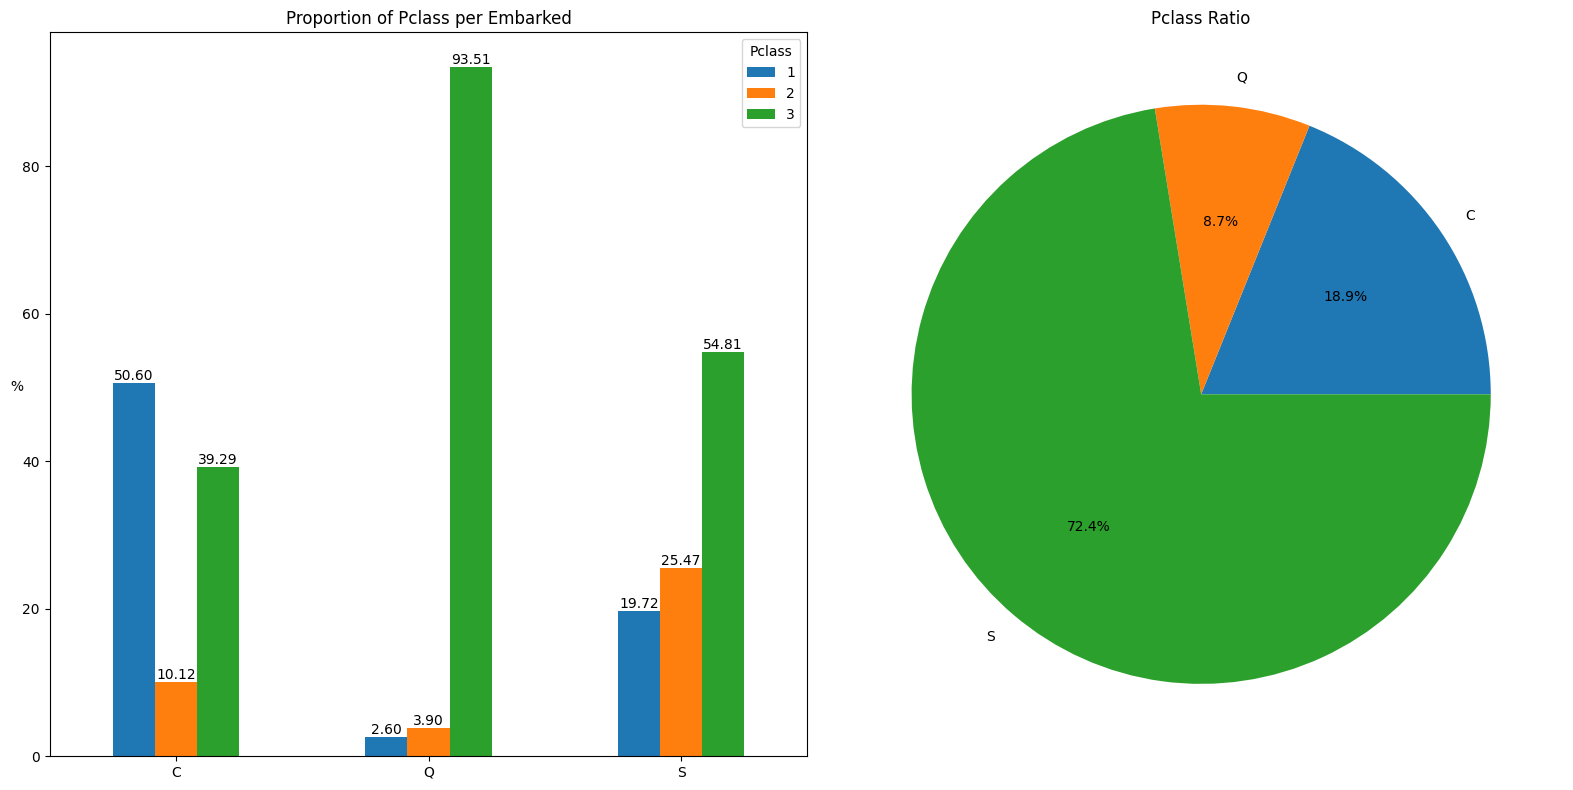

Result: statistically significant (p = 8.43527e-26)
Correlation (Cramér's V): 0.264 (moderate association)


In [189]:
gr = group_by_2_cols(df_train, col_1='Pclass', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Pclass', col_2='Embarked')
is_significant(gr)

Queenstown seemed to be primarily a boarding point for 3r class passengers with 93.51%, while Cherbourg had over 50% of passengers from the upper classes. 

Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217


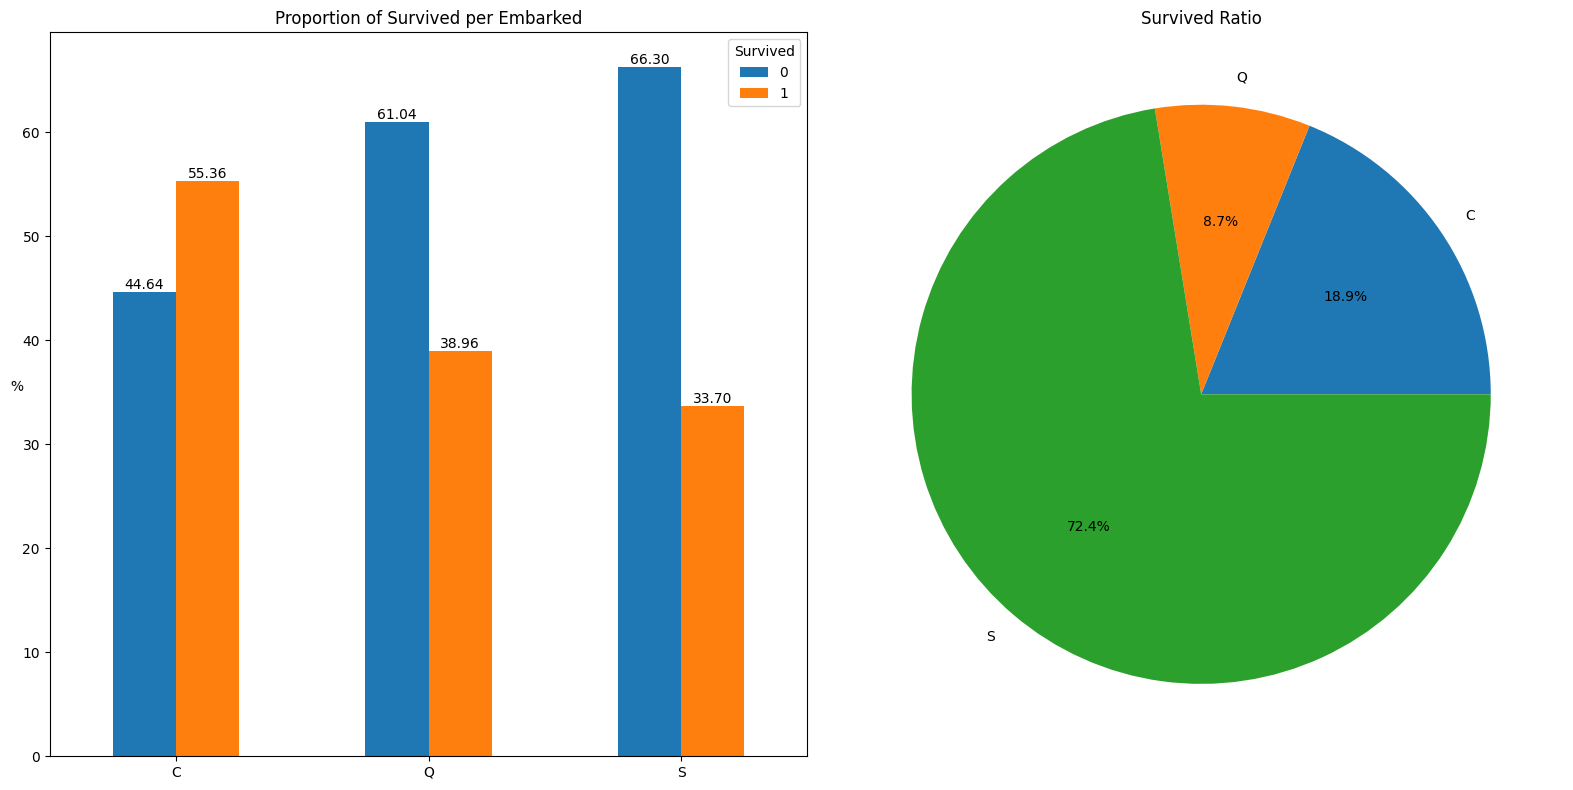

Result: statistically significant (p = 1.76992e-06)
Correlation (Cramér's V): 0.173 (weak association)


In [190]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Survived', col_2='Embarked')
is_significant(gr)

There is a strong correlation between embarkation port and survival. Passengers boarding at Cherbourg were significantly more likely to survive than those from Queenstown or Southampton. This disparity is largely driven by socioeconomic class, as Cherbourg was a key entry point for 1st class passengers, while Queenstown served primarily 3rd class travellers.

### Pclass

Total number of Pclass: 891


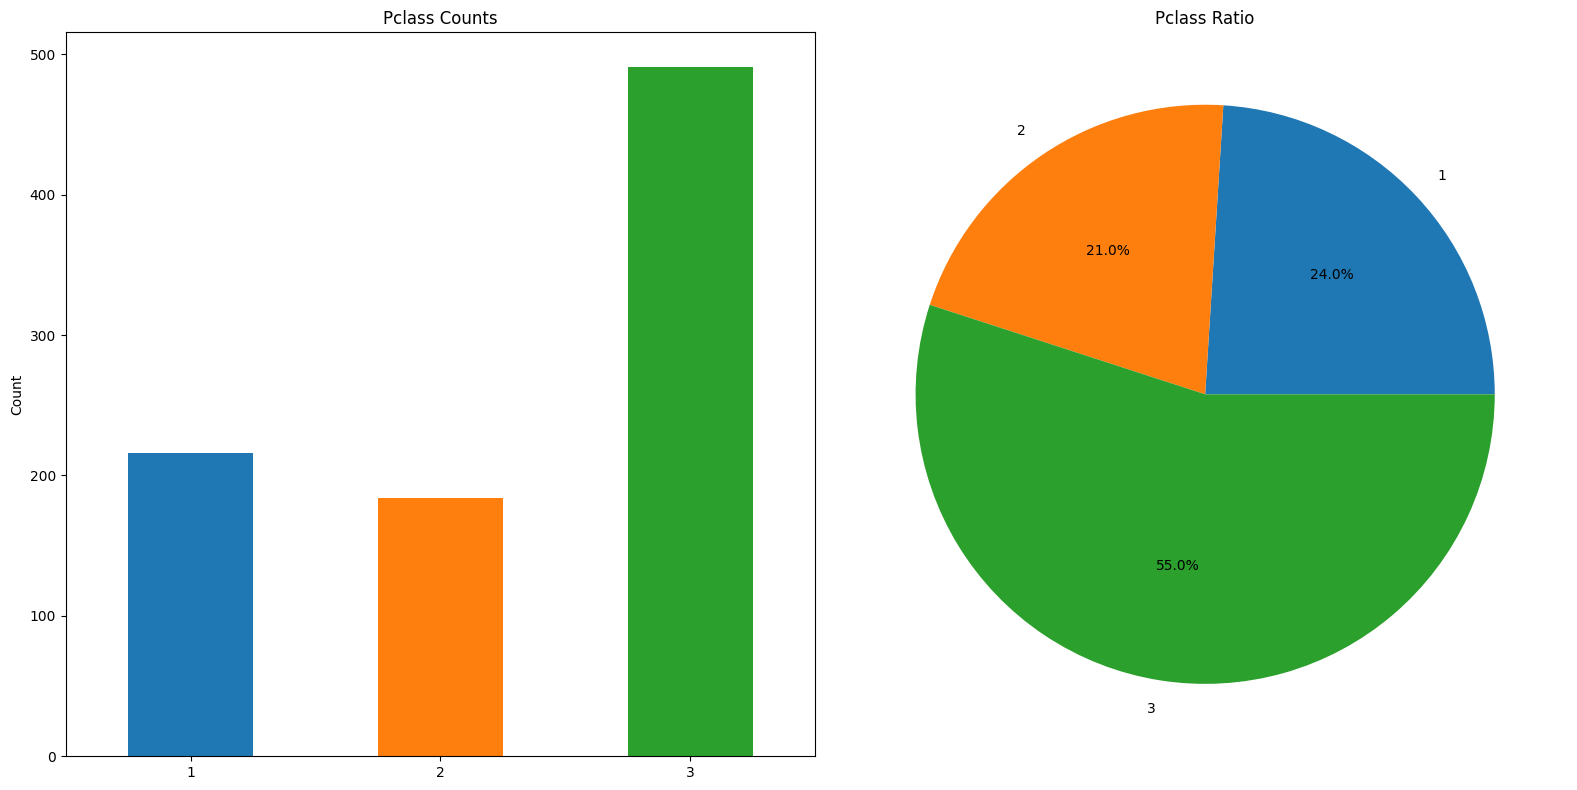

In [191]:
group_by_col_and_plot(df_train, col='Pclass')

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


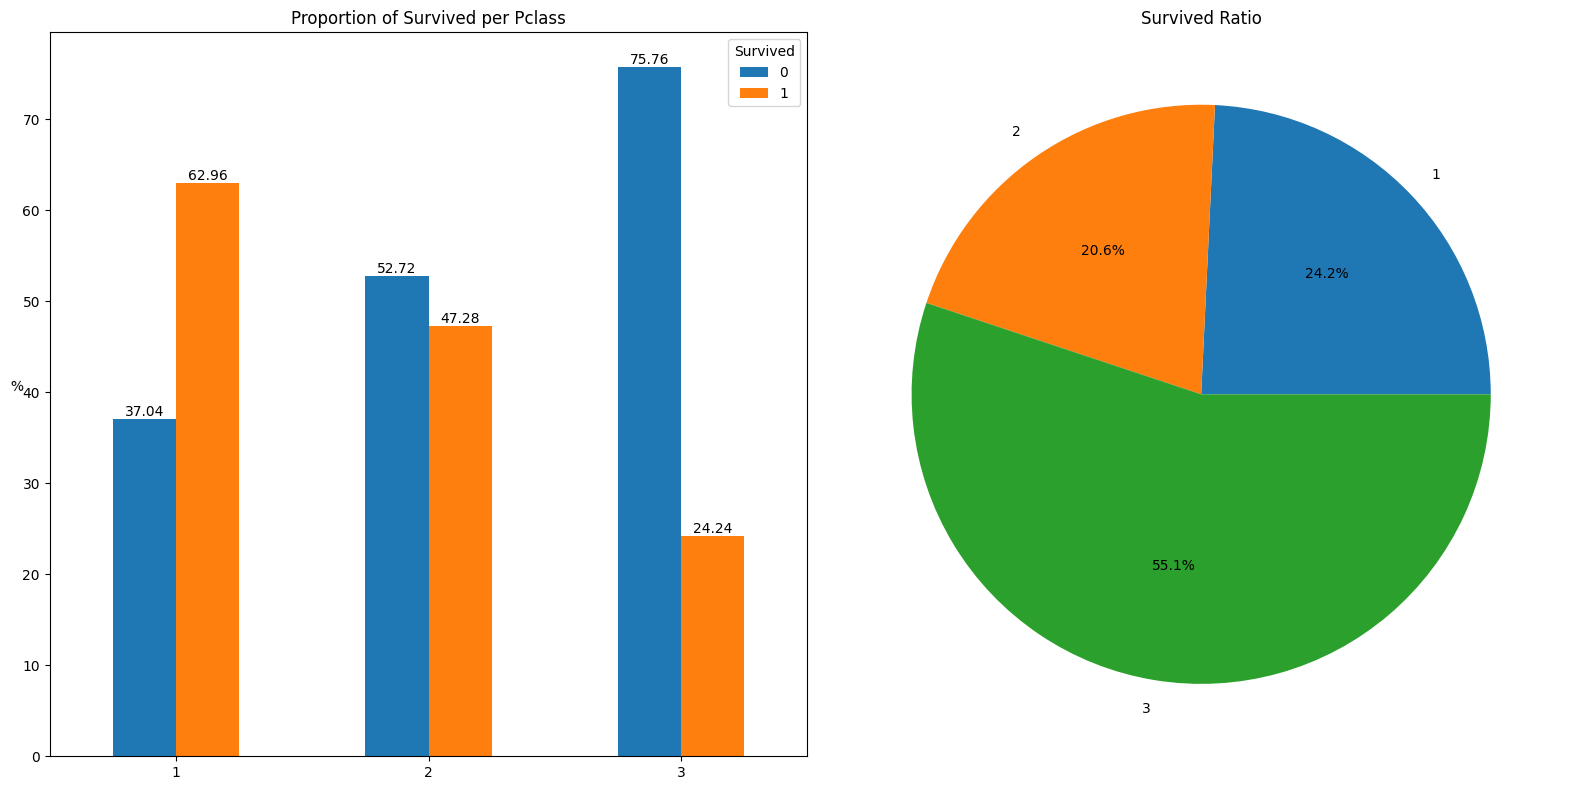

Result: statistically significant (p = 4.54925e-23)
Correlation (Cramér's V): 0.340 (moderate association)


In [192]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Pclass')
plot_2_cols_chart(gr, col_1='Survived', col_2='Pclass')
is_significant(gr)

As expected, 1st class had the highest surval rate, while 3rd class had the lowest. It seemed that there was a strong positive correlation between Fare, Pclass, and Survival.

## Feature Engineering

### Name

Names are in the format of {Last Name}, {Title}. {First Name}. It would be useful to extract the titles and last names to gain information about classes and family relations

In [193]:
def extract_title_and_last_name(name: str):
    if not name or not name.strip():
        return None, None
    
    parts = name.split(', ')
    
    last_name = parts[0] if len(parts) > 0 else None  # Remove last char
    title = parts[1].split('. ')[0] if len(parts) > 1 else None
    
    return title, last_name
df_train[['Title', 'Lastname']] = df_train['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x)))
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen


Mapping specific titles to generalized groups to create high-signal feature that explicitly encodes the social hierarchy including Gender, Age, Status. Some titles only exist in train or test dataset, it is best to create a universal mapping to cover as many titles as possible.

In [194]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Ms': 'Miss',
    'Master': 'Master',
    'Mme': 'Mrs',     # French for Mrs
    'Mlle': 'Miss',   # French for Miss
    'the Count': 'Noble',
    'the Countess': 'Noble_Female',
    'Count': 'Noble',
    'Coutess': 'Noble_Female',
    'Don': 'Noble',   # Not a Knight
    'Sir': 'Noble',   # Knight
    'Jonkheer': 'Noble',
    'Jonkvrouw': 'Noble_Female',
    'Earl': 'Noble',
    'Lord': 'Noble',
    'Lady': 'Noble_Female',
    'Dame': 'Noble_Female',
    'Major': 'Military',
    'Col': 'Military',
    'Capt': 'Military',
    'Dr': 'Academic',
    'Prof': 'Academic',
    'Rev': 'Religious'
}
    
df_train['Title'] = df_train['Title'].map(title_mapping)
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen


Total number of Title: 891


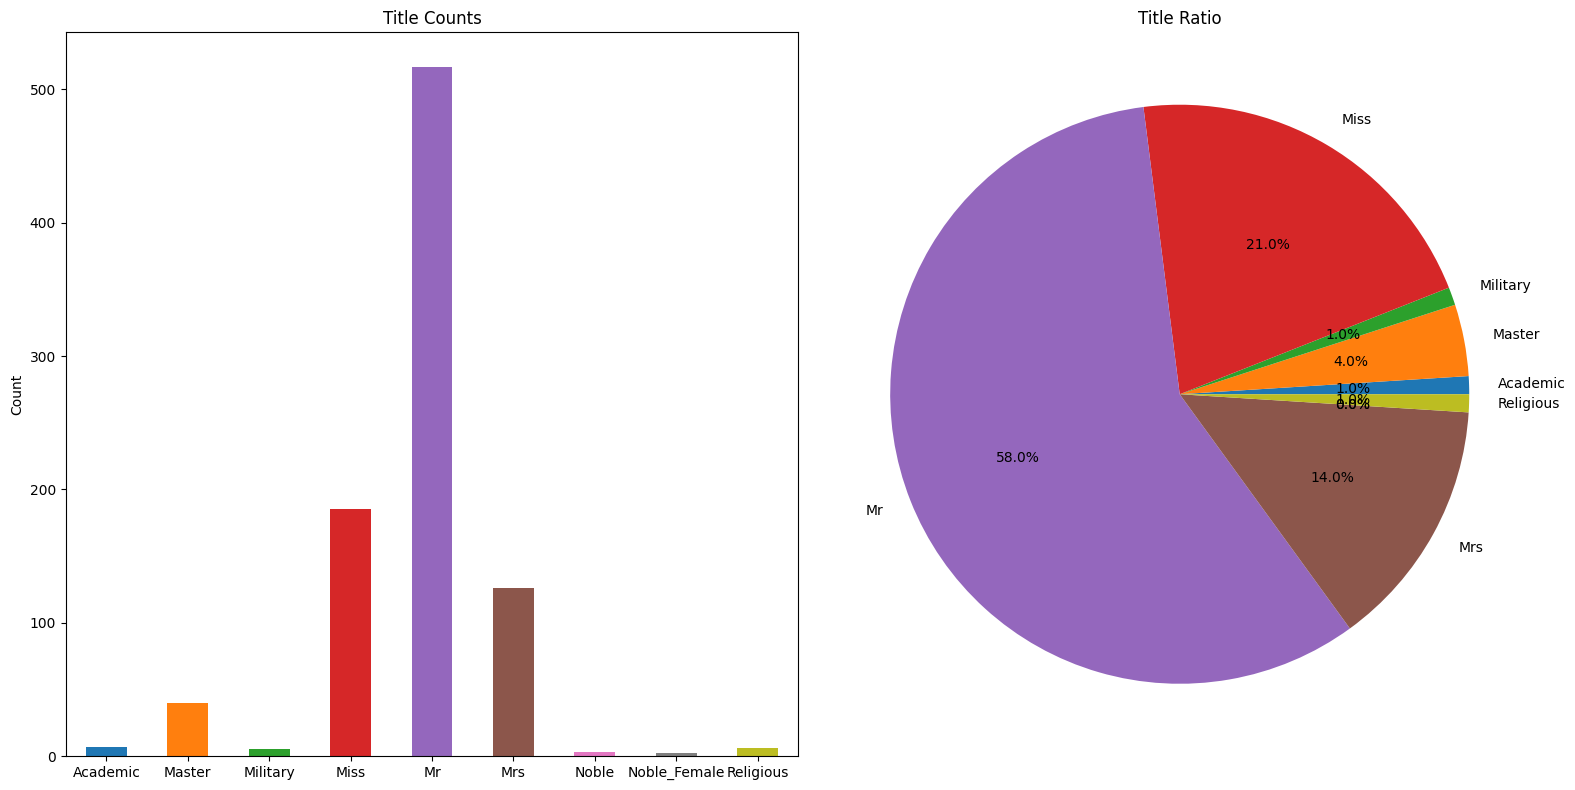

In [195]:
group_by_col_and_plot(df_train, 'Title')

Survived        0    1
Title                 
Academic        4    3
Master         17   23
Military        3    2
Miss           55  130
Mr            436   81
Mrs            26  100
Noble           2    1
Noble_Female    0    2
Religious       6    0


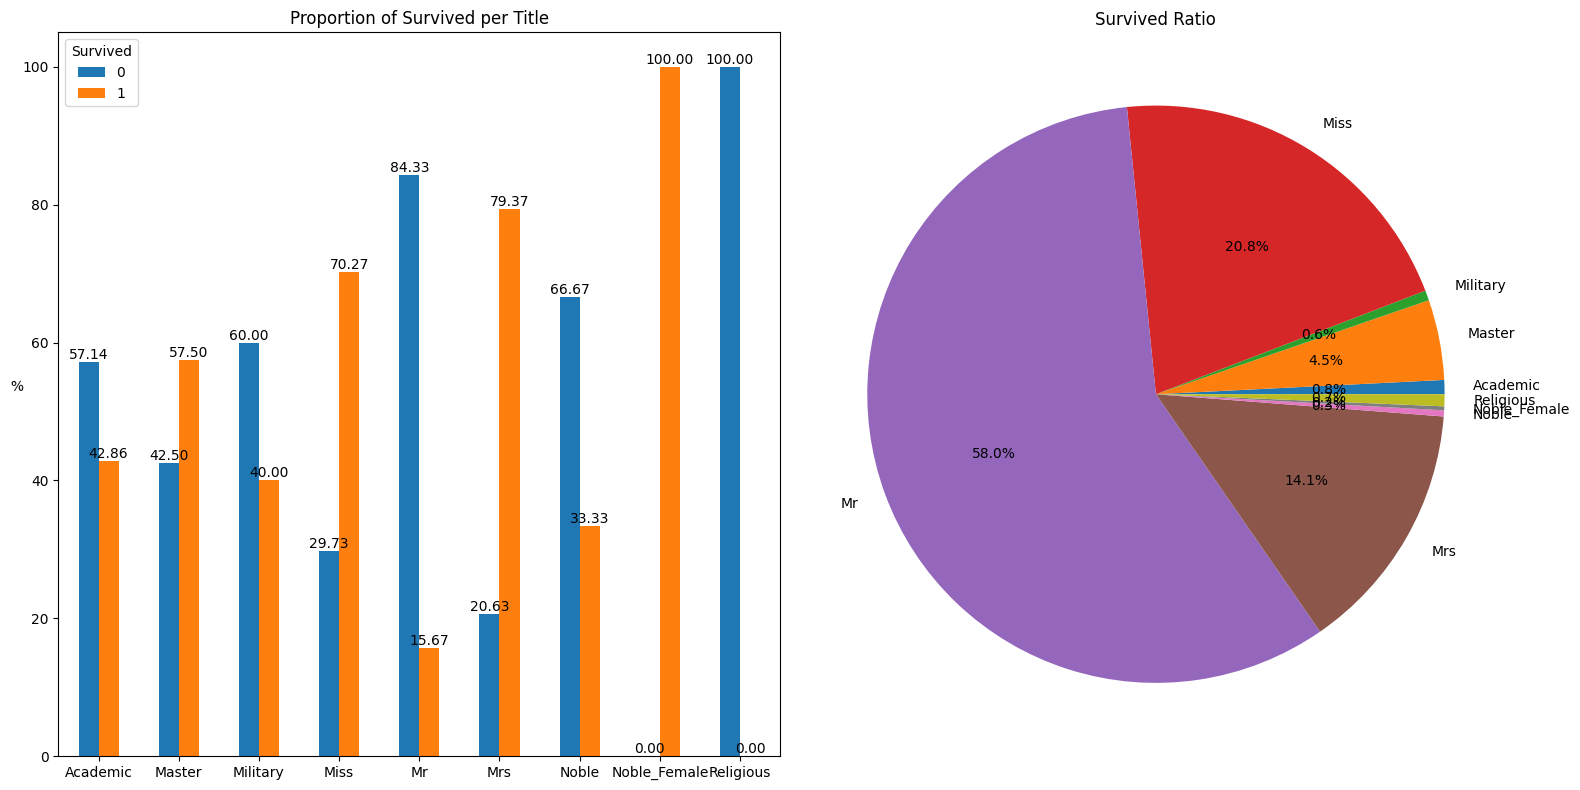

Result: statistically significant (p = 4.68467e-59)
Correlation (Cramér's V): 0.575 (moderate association)


In [196]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Title')
plot_2_cols_chart(gr, col_1='Survived', col_2='Title')
is_significant(gr)

It seems that Master, Miss, Mrs, and Noble_Female titles are titles strongly correlated to Survival

### Family Size

Combine SibSp and Parch as FamilySize

FamilySize = SibSp + Parch + 1 to account for all members in the family including the person we are looking at

In [197]:
def create_family_size(df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df.drop(['SibSp', 'Parch'], axis=1)

    return df

df_train = create_family_size(df_train)
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen,1


Total number of FamilySize: 891


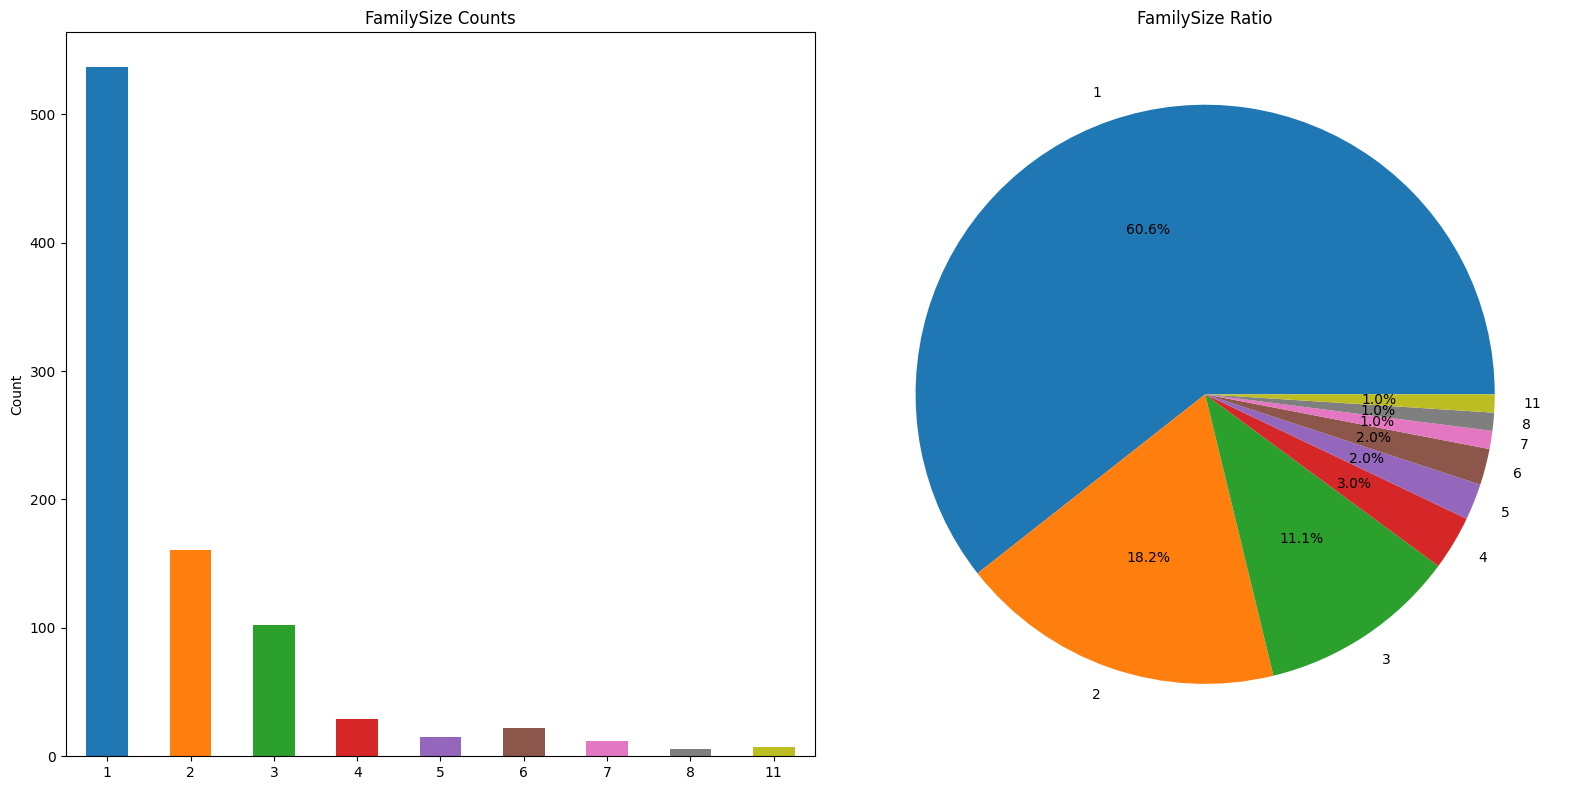

In [198]:
group_by_col_and_plot(df_train, 'FamilySize')

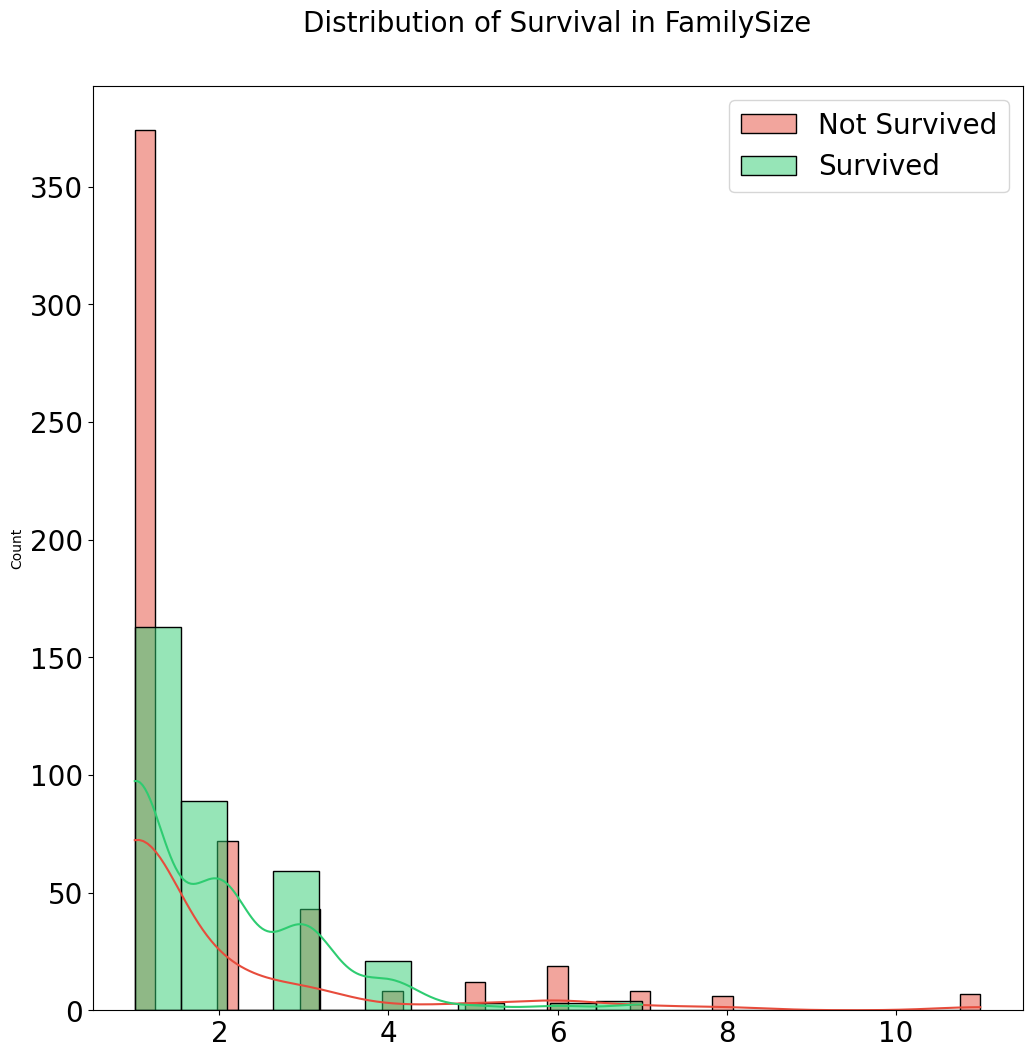

In [199]:
distribution_plot(df_train, col='FamilySize')

Survived      0    1
FamilySize          
1           374  163
2            72   89
3            43   59
4             8   21
5            12    3
6            19    3
7             8    4
8             6    0
11            7    0


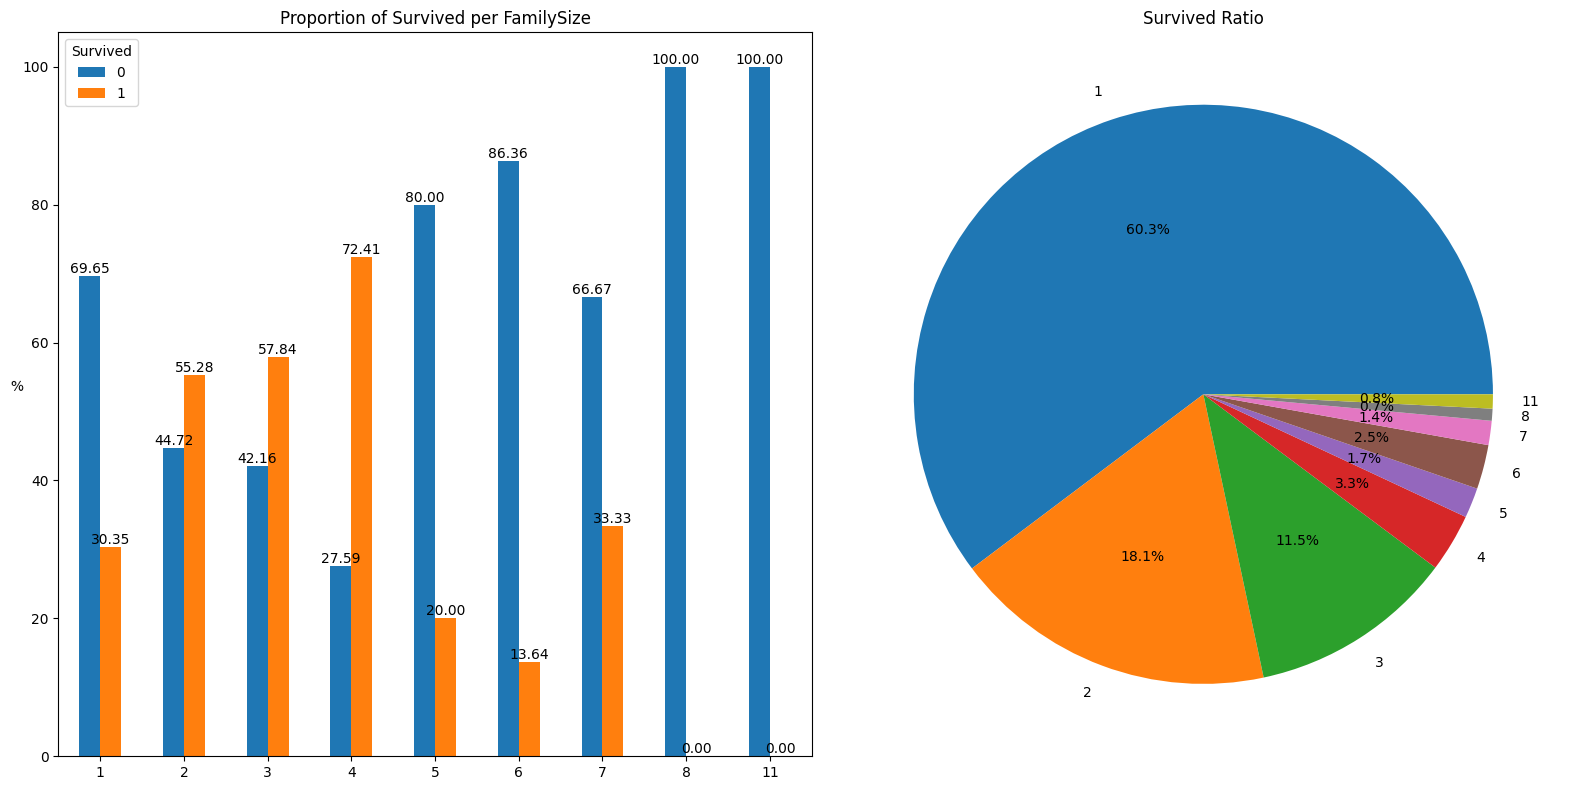

Result: statistically significant (p = 3.57967e-14)
Correlation (Cramér's V): 0.301 (moderate association)


In [200]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='FamilySize')
plot_2_cols_chart(gr, col_1='Survived', col_2='FamilySize')
is_significant(gr)

Family Sizes 2 - 4 show favorable survival ratios (>55%).\
Solo travelers had 30.4% survival rate, similar to overall survival as they account for most of the passengers.\
Large families size 5-11 had extremely poor survivalbility.

### Age

#### Fill missing ages

In [201]:
missing_mask = df_train['Age'].isna()

def fill_missing_ages(df):
    df = df.fillna({'Age': df.groupby(['Title', 'Pclass', 'FamilySize', 'Sex'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Age': df.groupby(['Title'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Age': df.groupby(['Pclass'], observed=False)['Age'].transform('median')})
    
    return df

df_train = fill_missing_ages(df_train)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_train[missing_mask])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
5,0,3,"Moran, Mr. James",male,27.00,0,0,330877,8.4583,NaN,Q,Mr,Moran,1
17,1,2,"Williams, Mr. Charles Eugene",male,30.00,0,0,244373,13.0000,NaN,S,Mr,Williams,1
19,1,3,"Masselmani, Mrs. Fatima",female,47.00,0,0,2649,7.2250,NaN,C,Mrs,Masselmani,1
26,0,3,"Emir, Mr. Farred Chehab",male,27.00,0,0,2631,7.2250,NaN,C,Mr,Emir,1
28,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,22.00,0,0,330959,7.8792,NaN,Q,Miss,O'Dwyer,1
29,0,3,"Todoroff, Mr. Lalio",male,27.00,0,0,349216,7.8958,NaN,S,Mr,Todoroff,1
31,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,38.50,1,0,PC 17569,146.5208,B78,C,Mrs,Spencer,2
32,1,3,"Glynn, Miss. Mary Agatha",female,22.00,0,0,335677,7.7500,NaN,Q,Miss,Glynn,1
36,1,3,"Mamee, Mr. Hanna",male,27.00,0,0,2677,7.2292,NaN,C,Mr,Mamee,1
42,0,3,"Kraeff, Mr. Theodor",male,27.00,0,0,349253,7.8958,NaN,C,Mr,Kraeff,1


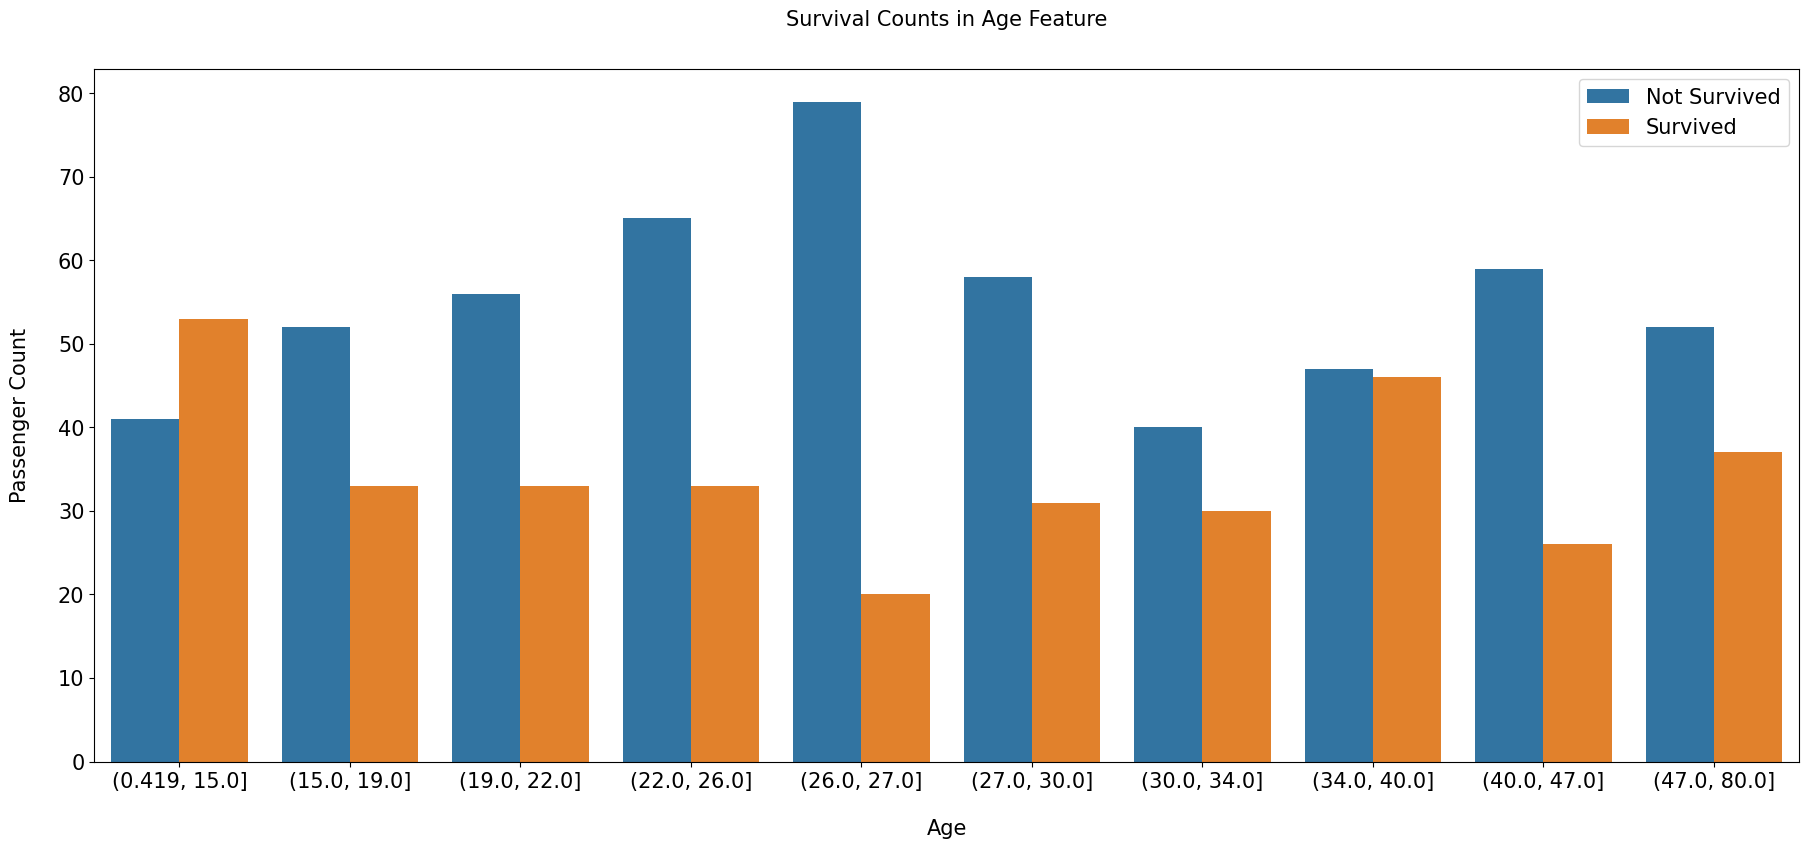

In [202]:
age_survive = pd.DataFrame({
    'Age': pd.qcut(df_train['Age'], q=10, duplicates='drop'),
    'Survived': df_train['Survived']
})
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Age', hue='Survived', data=age_survive)

plt.xlabel('Age', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Survival Counts in {} Feature'.format('Age'), size=15, y=1.05)

plt.show()

Age 0-14 show favorable survival ratio. And suprisingly age 30-40 also had a high survival ratio\

In [203]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)].sort_values('Sex', ascending=True))

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings,2
383,1,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,1,0,113789,52.0000,NaN,S,Mrs,Holverson,2
375,1,1,"Meyer, Mrs. Edgar Joseph (Leila Saks)",female,38.5,1,0,PC 17604,82.1708,NaN,C,Mrs,Meyer,2
357,0,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,NaN,S,Miss,Funk,1
346,1,2,"Smith, Miss. Marion Elsie",female,40.0,0,0,31418,13.0000,NaN,S,Miss,Smith,1
334,1,1,"Frauenthal, Mrs. Henry William (Clara Heinshei...",female,38.5,1,0,PC 17611,133.6500,NaN,S,Mrs,Frauenthal,2
716,1,1,"Endres, Miss. Caroline Louise",female,38.0,0,0,PC 17757,227.5250,C45,C,Miss,Endres,1
328,1,3,"Goldsmith, Mrs. Frank John (Emily Alice Brown)",female,31.0,1,1,363291,20.5250,NaN,S,Mrs,Goldsmith,3
327,1,2,"Ball, Mrs. (Ada E Hall)",female,36.0,0,0,28551,13.0000,D,S,Mrs,Ball,1
325,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C,Miss,Young,1


In [204]:
# Check Gender Balance
print(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Sex'].value_counts())

# Check Class Balance
print(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Pclass'].value_counts())

# Cross-tabulate Check
print(pd.crosstab(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Pclass'], df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Sex']))
print(pd.crosstab(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Sex'], df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Survived']))
print(pd.crosstab(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Pclass'], df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Survived']))  

Sex
male      124
female     76
Name: count, dtype: int64
Pclass
3    74
1    64
2    62
Name: count, dtype: int64
Sex     female  male
Pclass              
1           37    27
2           22    40
3           17    57
Survived   0   1
Sex             
female    11  65
male      98  26
Survived   0   1
Pclass          
1         14  50
2         36  26
3         59  15


It seems like this can be explained by the large portion of people from this age group are either female or first class passenger: 103/200(>50%), while the total number of survivors of this group is only 91

### Fare

#### Fill missing fares

In [223]:
def fill_missing_fares(df):
    df['Fare'] = df['Fare'].replace(0, np.nan)
    df = df.fillna({'Fare': df.groupby(['Title', 'Pclass', 'FamilySize'], observed=False)['Fare'].transform('median')})
    df = df.fillna({'Fare': df.groupby(['Title', 'Pclass'], observed=False)['Fare'].transform('median')})
    
    return df

df_train = fill_missing_fares(df_train)

### Embarked

In [213]:
def fill_missing_embarked(df):
    df = df.fillna({'Embarked': df.groupby(['Title', 'Pclass', 'FamilySize'], observed=False)['Embarked'].transform(lambda x: x.mode()[0])})
    df = df.fillna({'Embarked': df.groupby(['Lastname'], observed=False)['Embarked'].transform(lambda x: x.mode()[0])})
    
    return df

df_train = fill_missing_embarked(df_train)

### Cabin

In [220]:
df = pd.read_csv('../data/raw/train.csv')
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [224]:
df_train.sort_values('Fare')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
378,0,3,"Betros, Mr. Tannous",male,20.0,0,0,2648,4.0125,NaN,C,Mr,Betros,1
872,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,Mr,Carlsson,1
326,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S,Mr,Nysveen,1
843,0,3,"Lemberopolous, Mr. Peter L",male,34.5,0,0,2683,6.4375,NaN,C,Mr,Lemberopolous,1
818,0,3,"Holm, Mr. John Fredrik Alexander",male,43.0,0,0,C 7075,6.4500,NaN,S,Mr,Holm,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,Miss,Fortune,6
341,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S,Miss,Fortune,6
737,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,Mr,Lesurer,1
679,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,Mr,Cardeza,2


## Training

In [36]:

import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    
    df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x))).astype('category')
    
    # Standardize titles
    title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
    df['Title'] = df['Title'].map(title_mapping)

    # Create mask for title replacement
    title_mask = ~df['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master'])
    df.loc[title_mask, 'Title'] = df.loc[title_mask, 'Sex'].map({'male': 'Mr', 'female': 'Mrs'})
    df['Title'] = df['Title'].astype('category')
    df['Title'] = df['Title'].map({'Miss': 0, 'Mrs': 1, 'Master': 2, 'Mr': 3}).astype(int)
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Fare'] = df['Fare'] * df['FamilySize'].astype(float)
    
    df['FamilySize'] = (pd.cut(df['FamilySize'], bins=[0, 2, 5, np.inf], labels=['Solo', 'Average', 'Large']))
    df['FamilyID'] = df['LastName'].astype(str) + df['FamilySize'].astype(str)
    df['FamilySize'] = df['FamilySize'].map({'Average': 0, 'Solo': 1, 'Large': 2}).astype(int)
    
    df = df.fillna({'Age': df.groupby(['Title', 'Pclass'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Embarked': df.groupby(['FamilyID', 'Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Embarked': df.groupby(['Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['FamilyID', 'Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass', 'Embarked'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    
    if 'Sex' in df.columns:
        df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2}).astype(int)
    df['Cabin'] = df['Cabin'].map(lambda x: ord(x[0]) - ord('A')).astype(int)
    if 'Pclass' in df.columns:
        df['Pclass'] = df['Pclass'] - 1
    
    df = df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'LastName', 'FamilyID', 'Cabin'], axis=1)

    return df

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
df = pd.read_csv('../data/raw/train.csv')
df['Ticket'].nunique()

681

In [38]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print(df.dtypes)

target_col = 'Survived'

models = []
best_iterations_list = []

base_model = RandomForestClassifier(criterion='gini', 
                                           n_estimators=1100,
                                           max_depth=5,
                                           min_samples_split=4,
                                           min_samples_leaf=5,
                                           max_features='sqrt',
                                           oob_score=True,
                                           random_state=13,
                                           n_jobs=-1,
                                           verbose=1)

X = df.drop(columns=[target_col])
y = df[target_col]

# base_model = RandomForestClassifier(
#         n_estimators=300,
#         max_depth=7,
#         random_state=42,
#         n_jobs=-1
# )
    
with mlflow.start_run():
    # Define K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=13)
    
    # Lists to store metrics for each fold
    accuracies, recalls, f1s = [], [], []
    
    # Loop through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
        # Train model
        model = base_model
        model.fit(X_train_fold, y_train_fold)

        preds = model.predict(X_test_fold)
        models.append(model)
        
        # Calculate metrics
        acc = accuracy_score(y_test_fold, preds)
        rec = recall_score(y_test_fold, preds)
        f1 = f1_score(y_test_fold, preds)
        
        # Store metrics
        accuracies.append(acc)
        recalls.append(rec)
        f1s.append(f1)
        
        # Log metrics for this fold
        mlflow.log_metric(f"accuracy_fold", acc, step=fold)
        mlflow.log_metric(f"recall_fold", rec, step=fold)
    
    # Log average and standard deviation
    mlflow.log_metric("accuracy_mean", np.mean(accuracies))
    mlflow.log_metric("accuracy_std", np.std(accuracies))
    mlflow.log_metric("recall_mean", np.mean(recalls))
    mlflow.log_metric("recall_std", np.std(recalls))
    
    # Log parameters and dataset
    mlflow.log_param("n_estimators", 300)
    train_ds = mlflow.data.from_pandas(df, source="training_data")
    mlflow.log_input(train_ds, context="training")
    
    print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    
# final_n_estimators = int(np.mean(best_iterations_list))
# final_model = XGBClassifier(
#     n_estimators=final_n_estimators,
#     learning_rate=0.1,
#     max_depth=7,
#     random_state=42,
#     n_jobs=-1,
#     enable_categorical=True,
#     eval_metric="logloss"
# )
# final_model.fit(X, y)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


ValueError: could not convert string to float: 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'

In [ ]:
indices = np.where(y_test_fold != preds)[0]
print(indices)

false_preds = df.iloc[indices].sort_values('Survived')
print(false_preds)

[ 3 21 52 56 69 74 80]
    Survived  Pclass  Sex   Age      Fare  Embarked  Title  FamilySize
80         0       2    0  22.0    9.0000         2      3           1
69         0       2    0  26.0   25.9875         2      3           0
3          1       0    1  35.0  106.2000         2      1           1
21         1       1    0  34.0   13.0000         2      3           1
56         1       1    1  21.0   10.5000         2      1           1
52         1       0    1  49.0  153.4584         0      1           1
74         1       2    0  32.0   56.4958         2      3           1


In [ ]:
indices = np.where(y_test_fold == preds)[0]
print(indices)

true_preds = df.iloc[indices].sort_values('Survived')
print(true_preds[40:60])

[ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 53 54 55 57 58 59 60 61 62 63 64 65 66 67 68 70 71 72 73 75 76 77
 78 79 81 82 83 84 85 86 87 88]
    Survived  Pclass  Sex   Age      Fare  Embarked  Title  FamilySize
86         0       2    0  16.0  171.8750         2      3           0
77         0       2    0  25.0    8.0500         2      3           1
75         0       2    0  25.0    7.6500         2      3           1
76         0       2    0  25.0    7.8958         2      3           1
73         0       2    0  26.0   28.9084         0      3           1
72         0       1    0  21.0   73.5000         2      3           1
71         0       2    1  16.0  375.2000         2      1           2
70         0       1    0  32.0   10.5000         2      3           1
32         1       2    1  21.5    7.7500         1      1           1
31         1       0    1  35.0  293.04

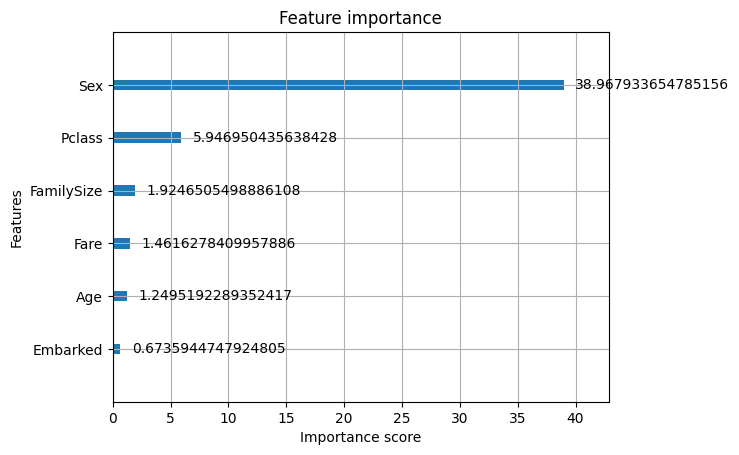

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance based on 'weight' (default), 'gain', or 'cover'
plot_importance(model, importance_type='gain', max_num_features=15)
plt.show()

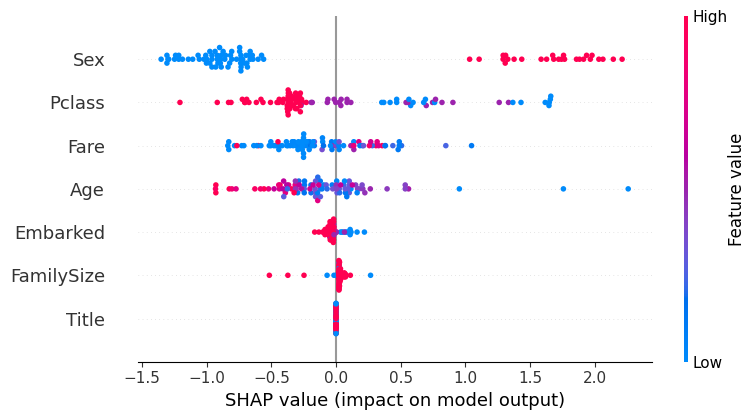

In [ ]:
import shap

# Create explainer and calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_fold)

# Visualize
shap.summary_plot(shap_values, X_test_fold)

In [ ]:
# Dump model to text with statistics
model.get_booster().dump_model('model.txt', with_stats=True)

# Read and parse the file to extract split patterns
import re
with open('model.txt', 'r') as f:
    txt_model = f.read()

# Extract patterns like [f2<2.45]
splits = re.findall(r'\[f([0-9]+)<([0-9.e-]+)\]', txt_model)
print(splits)

[]


In [ ]:
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    1.6s
[Parallel(n_jobs=8)]: Done 1100 out of 1100 | elapsed:    2.2s finished


In [ ]:

import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    
    df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x))).astype('category')
    
    # Standardize titles
    title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
    df['Title'] = df['Title'].map(title_mapping)

    # Create mask for title replacement
    title_mask = ~df['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master'])
    df.loc[title_mask, 'Title'] = df.loc[title_mask, 'Sex'].map({'male': 'Mr', 'female': 'Mrs'})
    df['Title'] = df['Title'].astype('category')
    df['Title'] = df['Title'].map({'Miss': 0, 'Mrs': 1, 'Master': 2, 'Mr': 3}).astype(int)
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Fare'] = df['Fare'] * df['FamilySize'].astype(float)
    
    df['FamilySize'] = (pd.cut(df['FamilySize'], bins=[0, 1, 5, np.inf], labels=['Solo', 'Average', 'Large']))
    df['FamilyID'] = df['LastName'].astype(str) + df['FamilySize'].astype(str)
    df['FamilySize'] = df['FamilySize'].map({'Average': 0, 'Solo': 1, 'Large': 2}).astype(int)
    # df['is_solo'] = (df['FamilySize'] == 1).astype(int)
    
    df = df.fillna({'Age': df.groupby(['Title', 'Pclass'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Embarked': df.groupby(['FamilyID', 'Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Embarked': df.groupby(['Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['FamilyID', 'Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass', 'Embarked'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    
    # df['Age'] = pd.cut(df['Age'], bins=[0, 6, 12, 25, 65, np.inf], labels=[0, 1, 2, 3, 4])
    # df['Title'] = df['Title'].map(lambda x: 0 if x == 'Mr' else (1 if x == 'Mrs' else 2))
    
    if 'Sex' in df.columns:
        df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2}).astype(int)
    df['Cabin'] = df['Cabin'].map(lambda x: ord(x[0]) - ord('A')).astype(int)   
    if 'Pclass' in df.columns:
        df['Pclass'] = df['Pclass'] - 1
    
    df = df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'LastName', 'FamilyID'], axis=1)

    return df

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from mlxtend.classifier import StackingCVClassifier
from sklearn.model_selection import cross_val_score
import sklearn

# sklearn.set_config(enable_metadata_routing=True)

# print(df.dtypes)

# target_col = 'Survived'

# X = df.drop(columns=[target_col])
# y = df[target_col]

# train_set_X, holdout_set_X, train_set_y, holdout_set_y = train_test_split(
#     X, 
#     y,
#     train_size=0.7, 
#     shuffle=True, 
#     random_state=0
# )

# # Define base models
# base_xgb = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.1,
#     max_depth=7,
#     random_state=42,
#     n_jobs=-1,
#     enable_categorical=True,
#     eval_metric="logloss"
# )

# bagging = BaggingClassifier(
#     estimator=base_xgb, 
#     n_estimators=100, 
#     max_samples=0.8,  # Each estimator sees 80% of the data
#     random_state=1
# )
# rfc = RandomForestClassifier(random_state=1)

# # Define meta-classifier
# lr = LogisticRegression()

# # Initialize StackingCVClassifier
# sclf = StackingCVClassifier(
#     classifiers=[rfc, bagging],
#     meta_classifier=lr,
#     random_state=42,
#     cv=3
# )

# sclf.fit(X, y)
# with mlflow.start_run():
#     # Define K-Fold
#     kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
#     # Lists to store metrics for each fold
#     accuracies = []
#     recalls = []
#     f1s = []
#     models = []
    
#     # Loop through each fold
#     for fold, (train_index, test_index) in enumerate(kf.split(X)):
#         X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
#         y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
#         eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
#         # Train model
#         model = stacked_model
#         model.fit(X_train_fold, y_train_fold)
#         # model.fit(X_train_fold, y_train_fold)
#         preds = model.predict(X_test_fold)
        
#         models.append(model)
#         # Calculate metrics
#         acc = accuracy_score(y_test_fold, preds)
#         rec = recall_score(y_test_fold, preds)
#         f1 = f1_score(y_test_fold, preds)
        
#         # Store metrics
#         accuracies.append(acc)
#         recalls.append(rec)
#         f1s.append(f1)
        
#         # Log metrics for this fold
#         mlflow.log_metric(f"accuracy_fold", acc, step=fold)
#         mlflow.log_metric(f"recall_fold", rec, step=fold)
    
#     # Log average and standard deviation
#     mlflow.log_metric("accuracy_mean", np.mean(accuracies))
#     mlflow.log_metric("accuracy_std", np.std(accuracies))
#     mlflow.log_metric("recall_mean", np.mean(recalls))
#     mlflow.log_metric("recall_std", np.std(recalls))
    
#     # Log parameters and dataset
#     mlflow.log_param("n_estimators", 300)
#     train_ds = mlflow.data.from_pandas(df, source="training_data")
#     mlflow.log_input(train_ds, context="training")
    
#     print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")

Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Cabin           int64
Embarked        int64
Title           int64
FamilySize      int64
dtype: object


KeyboardInterrupt: 

In [ ]:
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = sclf.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)